In [1]:
%matplotlib inline

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from functools import reduce

## 1D Mixture Models

In [3]:
# We have the true parameters
MU1 = 3
MU2 = 5
VAR1 = 0.5
VAR2 = 1.5

In [4]:
# Let's create the sample data from the distributions (K=2)
dist1 = np.random.normal(loc=MU1, scale=VAR1, size=10)
dist2 = np.random.normal(loc=MU2, scale=VAR2, size=10)

In [5]:
dist1, dist2

(array([2.41712912, 2.40102668, 3.44850321, 3.27671764, 2.13665895,
        4.1265625 , 3.11755027, 2.5325952 , 3.17068822, 2.58565471]),
 array([4.34401002, 4.62209306, 4.29654337, 3.31340025, 5.13890717,
        5.28447465, 3.04606009, 3.7245803 , 5.867446  , 7.24024951]))

In [6]:
label1 = np.array([1 for _ in range(len(dist1))])
label2 = np.array([2 for _ in range(len(dist2))])

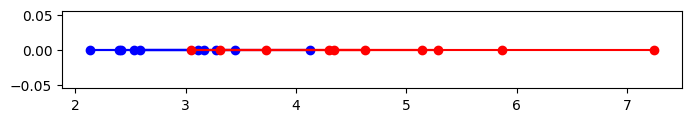

In [7]:
# Let's plot them
y = [0 for i in range(1,len(dist1)+1)]
plt.figure(figsize=(8,1))
plt.plot(dist1, y, color='blue', marker='o')
plt.plot(dist2, y, color='red', marker='o');

In [8]:
data = np.concat([dist1, dist2])
labels = np.concat([label1, label2])
data1 = pd.DataFrame(np.stack((data, labels), axis=1), columns=["values", "label"])
data1.head()

,values,label
0,2.417129,1.0
1,2.401027,1.0
2,3.448503,1.0
3,3.276718,1.0
4,2.136659,1.0


In [25]:
def normal_pdf(x, mean, var):
    prefactor = 1 / np.sqrt(2 * np.pi * var)
    exponent = np.exp(-((x - mean)**2) / (2 * var))
    
    return prefactor * exponent

In [26]:
def bayes_theorem(cond_prob1, cond_prob2, prior = 0.5):
    return (cond_prob1*prior)/((cond_prob1*prior) + (cond_prob2*prior))

In [11]:
data1["bayes_probs"] = data1["values"].apply(
    func=lambda x: bayes_theorem(
        cond_prob1=normal_pdf(x=x, mean=MU1, var=VAR1),
        cond_prob2=normal_pdf(x=x, mean=MU2, var=VAR2),
        )
    )

In [12]:
data1["predictions"] = data1["bayes_probs"].apply(func=lambda x: 1 if x >= 0.5 else 2)

In [13]:
data1[["label", "predictions"]]

,label,predictions
0,1.0,1
1,1.0,1
2,1.0,1
3,1.0,1
4,1.0,1
5,1.0,2
6,1.0,1
7,1.0,1
8,1.0,1
9,1.0,1


In [14]:
pred1 = data1["values"][data1["predictions"] == 1]
pred2 = data1["values"][data1["predictions"] == 2]

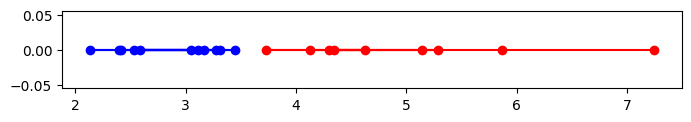

In [15]:
plt.figure(figsize=(8,1))
plt.plot(pred1, [0 for _ in range(len(pred1))], color="blue", marker="o")
plt.plot(pred2, [0 for _ in range(len(pred2))], color="red", marker="o");

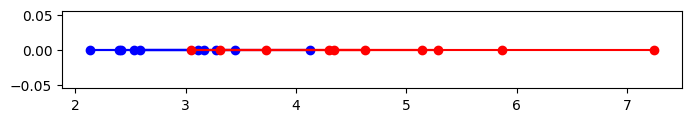

In [16]:
y = [0 for i in range(1,len(dist1)+1)]
plt.figure(figsize=(8,1))
plt.plot(dist1, y, color='blue', marker='o')
plt.plot(dist2, y, color='red', marker='o');

## Expectation Maximization

In [85]:
#1 Starting with random mean and variance for first distribution
initial_mu1 = np.random.uniform(high=2, size=1)
initial_var1 = np.random.uniform(high=2, size=1)
initial_mu2 = np.random.uniform(high=2, size=1)
initial_var2 = np.random.uniform(high=2, size=1)
initial_mu1, initial_var1, initial_mu2, initial_var2

(array([0.50715154]),
 array([1.49456587]),
 array([0.20201367]),
 array([1.90221537]))

In [86]:
#2 finding out bi'
bi_s = data1["values"].apply(
    func=lambda x: bayes_theorem(
        cond_prob1=normal_pdf(x=x, mean=initial_mu1, var=initial_var1),
        cond_prob2=normal_pdf(x=x, mean=initial_mu2, var=initial_var2),
        ).item()
    )
bi_s = np.array(bi_s)
ai_s = 1 - bi_s
bi_s, ai_s

(array([0.45757494, 0.45807833, 0.47267321, 0.44991282, 0.40556489,
        0.39852493, 0.49130008, 0.50213197, 0.34531828, 0.36200814,
        0.23387602, 0.49284125, 0.18159542, 0.18506736, 0.10131063,
        0.24250994, 0.10733876, 0.21789027, 0.1282187 , 0.38411881]),
 array([0.54242506, 0.54192167, 0.52732679, 0.55008718, 0.59443511,
        0.60147507, 0.50869992, 0.49786803, 0.65468172, 0.63799186,
        0.76612398, 0.50715875, 0.81840458, 0.81493264, 0.89868937,
        0.75749006, 0.89266124, 0.78210973, 0.8717813 , 0.61588119]))

In [96]:
# updated mu
num = reduce(lambda x, y: x + y[0]*y[1], zip(bi_s, data1["values"]), 0)
deno = reduce(lambda x, y: x + y, bi_s, 0)
updated_b_mu = (num/deno).item()

In [97]:
# updated var
num = reduce(lambda x, y: x + y[0]*((y[1] - updated_b_mu)**2), zip(bi_s, data1["values"]), 0)
deno = reduce(lambda x, y: x + y, bi_s, 0)
updated_b_var = (num/deno).item()

In [98]:
updated_b_mu, updated_b_var

(3.5512247943757083, 1.153125280586869)

In [ ]:
num = reduce(lambda x, y: x + y[0]*y[1], zip(ai_s, data1["values"]), 0)
deno = reduce(lambda x, y: x + y, ai_s, 0)
updated_a_mu = (num/deno).item()

num = reduce(lambda x, y: x + y[0]*((y[1] - updated_a_mu)**2), zip(ai_s, data1["values"]), 0)
deno = reduce(lambda x, y: x + y, ai_s, 0)
updated_b_var = (num/deno).item()

In [100]:
updated_a_mu, updated_b_var

(4.3438344810105445, 2.287869101548408)

#### Let's do all the the steps in a functions and loop it for few iterations

In [37]:
def expectation_maximization(values: pd.Series, iterations: int, initial_mu1: float, initial_mu2: float, initial_var1: float, initial_var2: float) -> pd.DataFrame:
    """Applies Expectation Maximization and find the mixture gaussian distributions that fits given data

    Args:
        values (pd.Series | np.array | list[float]): data

    Returns:
        pd.DataFrame: final dataframe that has the means and variances for each iterations
    """
    
    # Step 1: Generate random menas and variance for the two guassian distributions
    mu1 = initial_mu1
    var1 = initial_var1
    mu2 = initial_mu2
    var2 = initial_var2
    
    data = [
        {
            "updated_b_mu": mu1,
            "updated_b_var": var1,
            "updated_a_mu": mu2,
            "updated_a_var": var2
        }
    ]
    
    for _ in range(iterations):
        
        # Step 2: finding out bi's and ai's
        bi_s = values.apply(
            func=lambda x: bayes_theorem(
                cond_prob1=normal_pdf(x=x, mean=mu1, var=var1),
                cond_prob2=normal_pdf(x=x, mean=mu2, var=var2),
                ).item()
            )
        bi_s = np.array(bi_s)
        ai_s = 1 - bi_s
        
        # Step 3: calculating updated mean and var for the distributions
        num = reduce(lambda x, y: x + y[0]*y[1], zip(bi_s, values), 0)
        deno = reduce(lambda x, y: x + y, bi_s, 0)
        updated_b_mu = (num/deno).item()
        
        num = reduce(lambda x, y: x + y[0]*((y[1] - updated_b_mu)**2), zip(bi_s, values), 0)
        deno = reduce(lambda x, y: x + y, bi_s, 0)
        updated_b_var = (num/deno).item()
        
        num = reduce(lambda x, y: x + y[0]*y[1], zip(ai_s, values), 0)
        deno = reduce(lambda x, y: x + y, ai_s, 0)
        updated_a_mu = (num/deno).item()

        num = reduce(lambda x, y: x + y[0]*((y[1] - updated_a_mu)**2), zip(ai_s, values), 0)
        deno = reduce(lambda x, y: x + y, ai_s, 0)
        updated_a_var = (num/deno).item()
        
        # Step 4: updating the means and variances
        mu1 = updated_b_mu
        mu2 = updated_a_mu
        var1 = updated_b_var
        var2 = updated_a_var
        
        # Final Step: Building the dataframe
        row = {
            "updated_b_mu": updated_b_mu,
            "updated_b_var": updated_b_var,
            "updated_a_mu": updated_a_mu,
            "updated_a_var": updated_a_var
        }
        
        data.append(row)
        
    data = pd.DataFrame(data)
    return data

In [43]:
# Let's Test it 
params = expectation_maximization(values=data1["values"], iterations=10, initial_mu1=0.5, initial_mu2=1.0, initial_var1=1, initial_var2=0.5)
params

,updated_b_mu,updated_b_var,updated_a_mu,updated_a_var
0,0.500000,1.000000,1.000000,0.500000
1,4.116574,1.679803,2.793646,0.262255
2,4.509703,1.594900,2.876143,0.231165
3,4.618756,1.524998,2.889186,0.230480
4,4.657550,1.489906,2.891925,0.232473
5,4.673457,1.474042,2.892965,0.233847
6,4.680386,1.467145,2.893561,0.234634
7,4.683478,1.464217,2.893941,0.235084
8,4.684871,1.463011,2.894186,0.235347
9,4.685502,1.462540,2.894344,0.235506


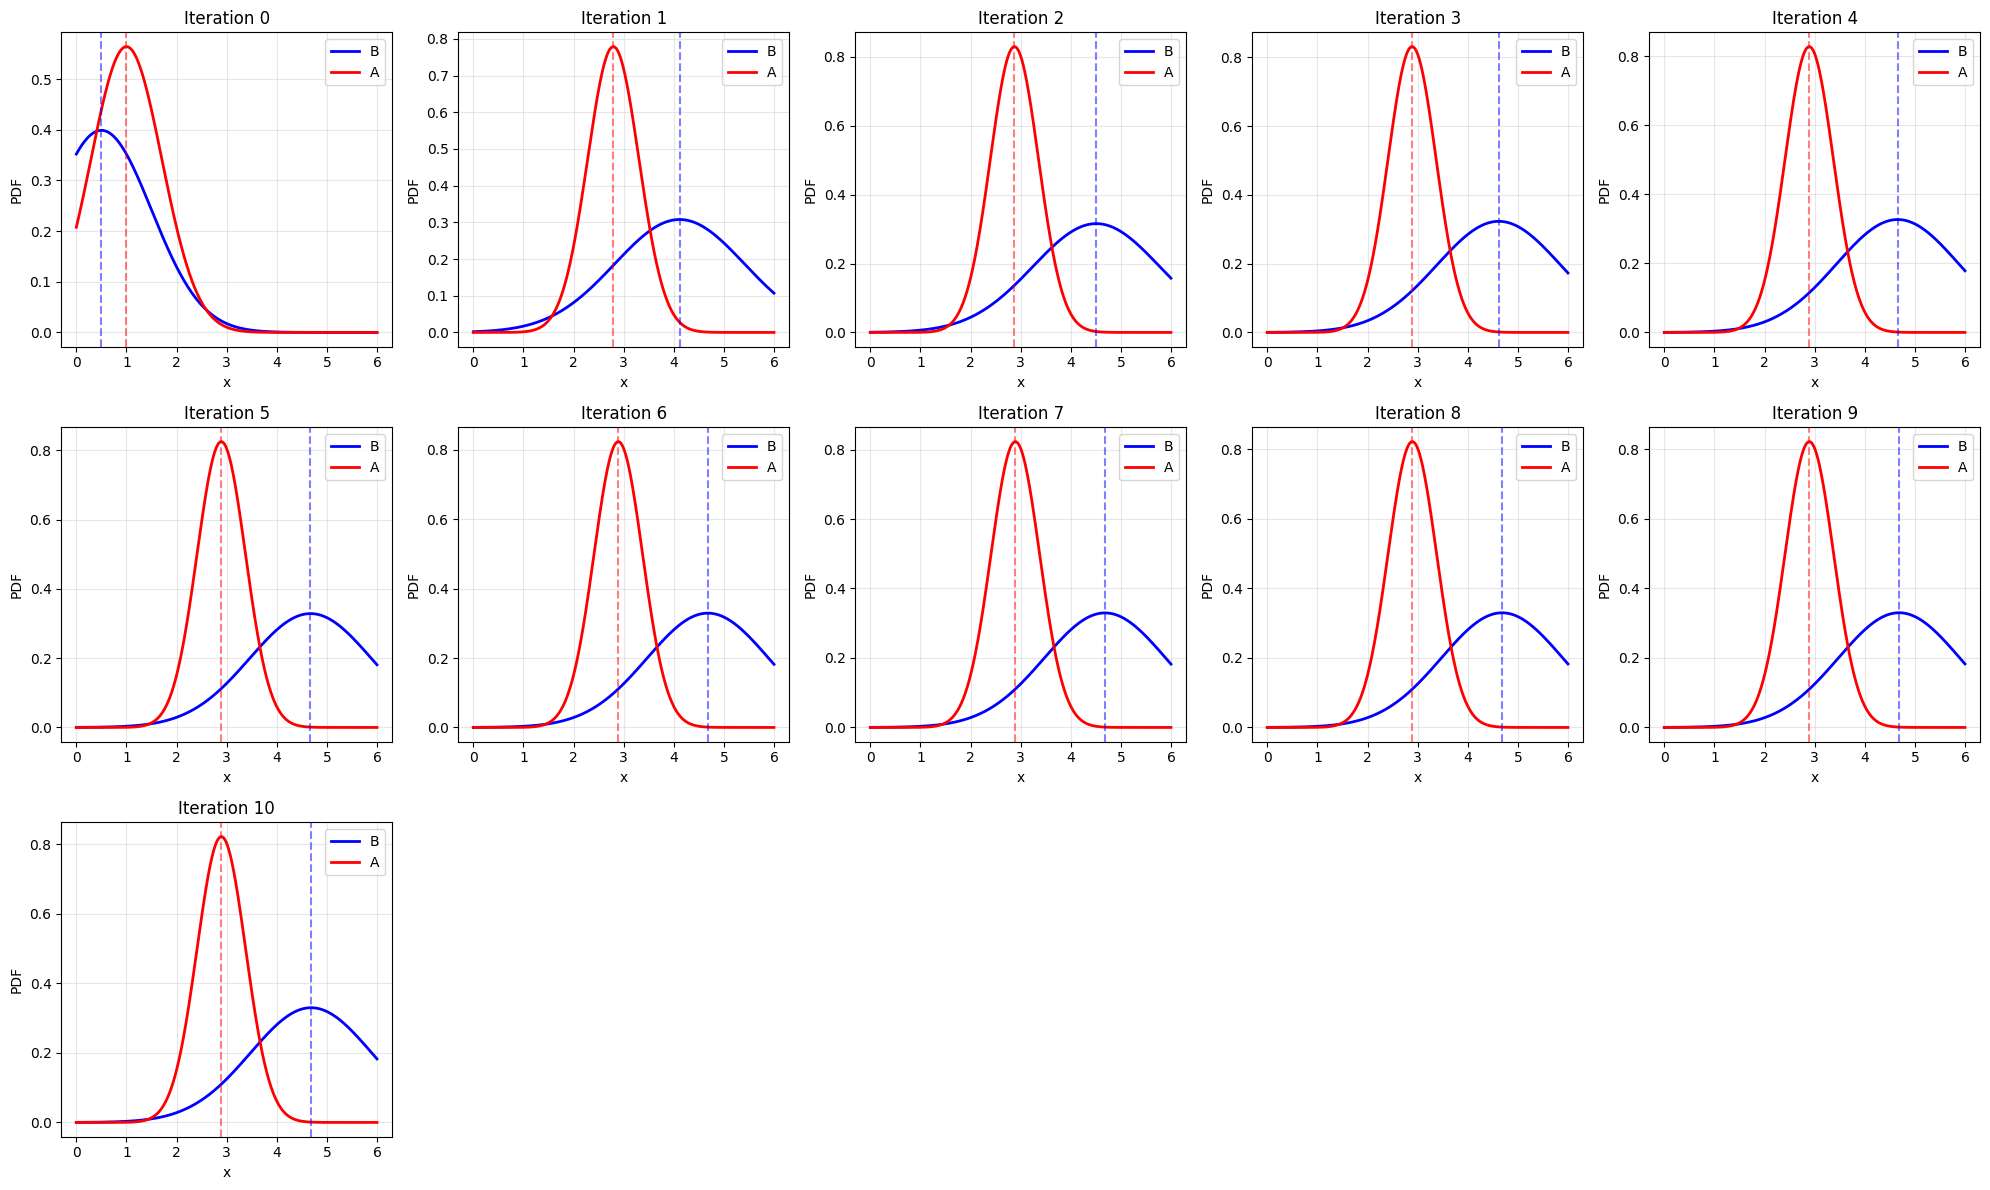

In [44]:
from scipy.stats import norm
import math

# 1. Determine the number of plots
n_plots = len(params)
n_cols = 5
# 2. Calculate required rows (ceiling division)
n_rows = math.ceil(n_plots / n_cols)

# 3. Create subplots with dynamic height
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes_flat = axes.flatten()

x = np.linspace(0, 6, 1000)

for i, (b_mu, b_var, a_mu, a_var) in enumerate(params.to_numpy()):
    ax = axes_flat[i]
    
    # Plot distributions
    ax.plot(x, norm.pdf(x, b_mu, np.sqrt(b_var)), 'b-', label='B', linewidth=2)
    ax.plot(x, norm.pdf(x, a_mu, np.sqrt(a_var)), 'r-', label='A', linewidth=2)
    
    # Mark means
    ax.axvline(b_mu, color='blue', linestyle='--', alpha=0.5)
    ax.axvline(a_mu, color='red', linestyle='--', alpha=0.5)
    
    ax.set_title(f'Iteration {i}')
    ax.set_xlabel('x')
    ax.set_ylabel('PDF')
    ax.legend()
    ax.grid(alpha=0.3)

# 4. Hide any unused empty subplots
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].axis('off')

plt.tight_layout()
plt.show()

### Final Check

In [46]:
params.columns

Index(['updated_b_mu', 'updated_b_var', 'updated_a_mu', 'updated_a_var'], dtype='object')

In [48]:
print(f"True Parameters: \nmu1: {MU1}\nmu2: {MU2}\nvar1: {VAR1}\nvar2: {VAR2}")
print(f"\nEstimated parameters using expectation maximization: \nmu1: {params.iloc[-1]["updated_b_mu"]}\nmu2: {params.iloc[-1]["updated_a_mu"]}\nvar1: {params.iloc[-1]["updated_b_var"]}\nvar2: {params.iloc[-1]["updated_a_var"]}")

True Parameters: 
mu1: 3
mu2: 5
var1: 0.5
var2: 1.5

Estimated parameters using expectation maximization: 
mu1: 4.6857886707865415
mu2: 2.8944467652873307
var1: 1.462373292224705
var2: 0.2356033486519825
